In [1]:
%reload_ext autoreload
%autoreload 2
import sys
sys.path.append(r'C:\Users\20561\Desktop\策略')
from fun import *
import polars as pl
import pandas as pd
import datetime as dt
import time 

logging = get_logger(log_file='实盘.log',inherit=False)

start_date = dt.date(2025,10,1)
end_date = dt.datetime.today()
end_date = dt.date(2026,2,12)

# 获取指定日期的日线数据
stock_data = read_day_data(start_date=start_date,end_date=end_date,file_path='ts_stock_all_data')
stock_data = stock_data.drop_nulls(subset=['open','close','pre_close','limit_up','limit_down'])
market_value = read_day_data(start_date=start_date,end_date=end_date,file_path='ts_daily_basic')
market_value = market_value.with_columns([
   ( pl.col('free_share')*pl.col('close')/1e4).alias('free_float_mv')
])
stock_data = stock_data.join(market_value.select(['code','trading_date','free_float_mv']),on=['code','trading_date'],how='left')
# stock_data.schema
# 去掉没用的列
stock_data = stock_data.drop(['change','total_share','attack','activity','pe','float_share','buying','selling','swing','strength','avg_turnover'])

In [ ]:
# 添加新一天的数据
from mapping import *
from stock_api import *
# from gm.api import *
# set_token('f60e5c28159d9dc4e3d51de7dd16d5e132f70841')

api = stock_api()

def gm_add_auction(stock_data):
    """"
    利用掘金接口增加早盘数据current(symbols=stock_list,include_call_auction=True),主要是获取open即可
    分成pl和pd分别处理
    """
    # 将stock_data最后一天的股票代码
    if isinstance(stock_data, pl.DataFrame):
        stock_data = stock_data.sort(['trading_date', 'code'])
        last_date = stock_data.select(pl.col('trading_date').max()).item()
        stock_list = stock_data.filter(pl.col('trading_date') == last_date).select(pl.col('code')).to_series().to_list()

        new_data = current(symbols=stock_list,include_call_auction=True)
        new_data = pd.DataFrame(new_data)
        new_data['trading_date'] = new_data['created_at']
        # 清洗数据
        new_data = clean_stocks_data(new_data)

        # 1. 将ts_data转为Polars
        new_data_pl = pl.from_pandas(new_data)
        
        # new_data_pl = new_data_pl.with_columns(
        #     pl.col('trading_date').str.strptime(pl.Date, "%Y-%m-%d").alias('trading_date')
        # )
        
        # 2. 统一所有列的数据类型（核心修复）
        # 先获取stock_data的完整schema
        target_schema = stock_data.schema
        
        # 逐个处理列：存在的列强制转换类型，不存在的列添加并设置类型
        for col, dtype in target_schema.items():
            if col in new_data_pl.columns:
                # 强制转换已有列的类型为stock_data的类型
                new_data_pl = new_data_pl.with_columns(
                    pl.col(col).cast(dtype).alias(col)
                )
            else:
                # 添加缺失列并设置类型
                new_data_pl = new_data_pl.with_columns(
                    pl.lit(None, dtype=dtype).alias(col)
                )
        
        
        # 4. 严格按照stock_data的列顺序排序
        new_data_pl = new_data_pl.select(stock_data.columns)

        
        
        # 5. 合并
        concat_data = stock_data.vstack(new_data_pl, in_place=False)
        # 5. 合并并重新排序（关键：确保时间顺序正确）
        concat_data = stock_data.vstack(new_data_pl, in_place=False)
        concat_data = concat_data.sort(by=['code', 'trading_date'])  # 按股票+日期排序

        # 6. 用前一交易日的close填充pre_close（核心修正）
        if 'pre_close' in concat_data.columns and 'close' in concat_data.columns:
            concat_data = concat_data.with_columns(
                pl.when(pl.col('pre_close').is_null())
                .then(pl.col('close').shift(1).over('code'))  # 取同一股票前一天的close
                .otherwise(pl.col('pre_close'))
                .alias('pre_close')
            )

        # 6. 补充pct有缺失的数据为(close/pre_close-1)*100
        if 'pct' in concat_data.columns and 'close' in concat_data.columns and 'pre_close' in concat_data.columns:
            concat_data = concat_data.with_columns(
                pl.when(pl.col('pct').is_null())
                .then((pl.col('close') / pl.col('pre_close') - 1) * 100)
                .otherwise(pl.col('pct'))
                .alias('pct')
            )
        

        # 7.填充缺失值,[free_float_mv,name,type_name,type,industry]这些列如果有缺失,则用前一交易日的填充（核心修正）
        need_cols = ['free_float_mv', 'name', 'type_name', 'type', 'industry']
        for col in need_cols:
            if col in concat_data.columns:
                concat_data = concat_data.with_columns(
                    pl.col(col).fill_null(pl.col(col).shift(1).over('code')).alias(col)
                )

        
        
    elif isinstance(stock_data, pd.DataFrame):
        # 1. 原始数据排序
        stock_data_sorted = stock_data.sort_values(by=['code', 'trading_date']).reset_index(drop=True)
        # 2. 取最后一个交易日
        last_date = stock_data_sorted['trading_date'].unique().max()
        # 3. 提取最后交易日的所有股票代码列表
        stock_list = stock_data_sorted[stock_data_sorted['trading_date'] == last_date]['code'].tolist()

        new_data = current(symbols=stock_list,include_call_auction=True)
        new_data = pd.DataFrame(new_data)
        new_data['trading_date'] = new_data['created_at']
        # 清洗数据
        new_data = clean_stocks_data(new_data)

        # 4. 获取需要给 ts_data 补充的列（stock_data 有而 ts_data 没有的列）
        # 使用 reindex 自动补齐并保留列顺序（pandas 会用 NaN/NaT 填充）
        new_data = new_data.reindex(columns=stock_data.columns)
        concat_data = pd.concat([stock_data, new_data], ignore_index=True)
        concat_data = concat_data.sort_values(by=['code', 'trading_date'])  # 按股票+日期排序
        
        # 5. 用前一交易日的close填充pre_close（核心修正）
        if 'pre_close' in concat_data.columns and 'close' in concat_data.columns:
            concat_data['pre_close'] = concat_data.groupby('code').apply(
                lambda group: group['pre_close'].fillna(group['close'].shift(1))
            ).reset_index(level=0, drop=True)  # 取同一股票前一天的close
    return concat_data

today = dt.date.today()
today = dt.date(2026,2,13)
today_str = today.strftime("%Y-%m-%d")
# 使用示例：
if stock_data is not None:
    if today in stock_data['trading_date'].unique():
        print(f"验证成功：数据中已包含 {today_str} 的行情")
    else:
        #stocks_data = ts_add_auction(stocks_data,m_ts)
        stocks_data = gm_add_auction(stock_data)
        # 检查是否成功添加了今天的数据
        if today in stocks_data['trading_date'].unique():
            if isinstance(stocks_data, pl.DataFrame):
                print(f"新增数据行数: {stocks_data.filter(pl.col('trading_date') == today).height}")
            else:
                print(f"新增数据行数: {len(stocks_data[stocks_data['trading_date'] == today])}")
        else:
            print(f"添加失败未发现 {today_str} 的新增数据")
else:
    print("没有历史数据可添加最新行情")


新增数据行数: 5183


In [3]:
# 1.涨停标记
# 标记涨停状态：limit_status
stocks_data = mark_limit_status(stocks_data)
# 标记涨停描述：limit_desc
stocks_data = mark_limit_desc(stocks_data)
# 记录最近的一次涨停描述：last_limit_desc
stocks_data = mark_last_limit_desc(stocks_data)
# 统计10天内涨停平均换手率
stocks_data = cal_limit_avg_turnover(stocks_data, window=5)

# 2.均线特征
# 计算均线:sma_{window}
stocks_data = add_sma(stocks_data, window=5)
stocks_data = add_sma(stocks_data, window=7)
"""
#stock_data = add_ema(stock_data, window=4)
#stock_data = add_ema(stock_data, window=7)
#stock_data = add_ewma_volatility(stock_data, window=8)
"""
# 3.计算开盘涨幅:open_chg,乖离率,成交均价vwap
stocks_data = stocks_data.with_columns(
    (
        (pl.col("open") - pl.col("pre_close")) 
        / pl.col("pre_close") 
        * 100
    ).alias("open_pct"),  # 开盘涨幅百分比
    ((pl.col("close") - pl.col("sma_7")) / pl.col("sma_7") * 100).alias("close_sma7_pct"), #乖离率
    (pl.col("amount")*100 / pl.col("volume")).alias("vwap"),
    ((pl.col("low") <= pl.col("limit_down")*1.01)).alias("touch_limit_down"), # 是否触及跌停
)
stocks_data = cal_n_lowest(stocks_data)

# 筛选stock_data行 为买入信号 1. 昨日涨停or断板or炸板   2.今日低开-3%至-4%  3.昨日收盘在昨日日五线上   4. 最近一次涨停描述 !=一天一板 或者 非空
# 1. 先确保数据按股票和日期排序
stocks_data = stocks_data.sort(["code", "trading_date"])

# 2. 在每个股票组内计算移位数据（关键步骤）
stocks_data = stocks_data.with_columns([
    # 同一股票内的前一天涨停状态
    pl.col("limit_status").shift(1).over("code").alias("prev_limit_status"),
    # 同一股票内的前一天5日均线
    pl.col("sma_7").shift(1).over("code").alias("prev_sma_7"),
    #pl.col("ema_7").shift(1).over("code").alias("prev_ema_7"),
    #pl.col("volume_ratio_5").shift(1).over("code").alias("pre_volume_ratio_5"),
    pl.col("pct").shift(1).over("code").alias("pre_pct"),
    pl.col("vwap").shift(1).over("code").alias("pre_vwap"),
    #pl.col("ewma_volatility_8").shift(1).over("code").alias("pre_ewma_volatility_8"),
    pl.col("close_sma7_pct").shift(1).over("code").alias("pre_close_sma7_pct"),
])

# 3. 基于组内移位后的数据筛选买入信号
# 条件参数字典
params_dict={
    'low':-5,
    'high':-2.5,
    'mv_min':35,
    'mv_max':1000,
    'prev_limit_status':['断板','炸板'],
    'avg_limit_turnover_5_min':-1
}

# 筛选数据并添加signal列
stocks_data = stocks_data.with_columns(
    # 构建筛选条件表达式
    signal = pl.when(
        # 非st,创业,科创
        ~(pl.col("type").is_not_null() & (pl.col("type") == "ST")) &
        ~(pl.col("code").str.split(".").list[1].str.starts_with("30") | 
          pl.col("code").str.split(".").list[1].str.starts_with("688")) &

        # 1. 昨日or断板or炸板（使用组内移位后的数据）
        (pl.col("prev_limit_status").is_in(params_dict['prev_limit_status'])) &

        # 2. 今日低开-3%至-4%
        (pl.col("open_pct") >= params_dict["low"]) & 
        (pl.col("open_pct") <= params_dict["high"]) &

        # 3. 昨日收盘在昨日5日均线上（注意你代码里写的是prev_sma_7，确认是否是笔误）
        (pl.col("pre_close") >= pl.col("prev_sma_7")) &

        # 4. 最近一次涨停描述 != 一天一板 且 非空
        (pl.col("last_limit_desc") != "1天1板") &
        (pl.col("last_limit_desc").is_not_null()) &

        # 5. 自由流通值区间
        (pl.col("free_float_mv") >= params_dict["mv_min"]) & 
        (pl.col("free_float_mv") <= params_dict["mv_max"]) &

        # 6. 最近的涨停平均换手率
        #(pl.col("avg_limit_turnover_5") >= params_dict["avg_limit_turnover_5_min"]) &

        # 6. 绝对位置不能太高，不能触发严重异动
        ((pl.col("open")/pl.col("lowest_30")) <= 3)
        
    ).then(1).otherwise(0)
)

# 如果需要只筛选出signal=1的行（可选）
信号文件 = stocks_data.filter(pl.col("signal") == 1)

logging.info(f"回测信号参数: {params_dict}")

回测信号参数: {'low': -5, 'high': -2.5, 'mv_min': 35, 'mv_max': 1000, 'prev_limit_status': ['断板', '炸板'], 'avg_limit_turnover_5_min': -1}


In [4]:
from trade_fun import *
start_date_str = start_date.strftime("%Y-%m-%d")
end_date_str = end_date.strftime("%Y-%m-%d")
#end_date_str = '2025-11-17'

logging.info(f"回测时间区间: {start_date_str} 至 {end_date_str}")
result_df,merged_df = cal_trade_info(信号文件,trade_fun=trade,start_date=start_date_str,end_date=end_date_str)

回测时间区间: 2025-10-01 至 2026-02-12
使用40个进程并行处理，共72个日期任务
回测任务进度: 100%|█████████████████████████| 72/72 [00:14<00:00,  4.86个日期/s]
所有回测任务完成，共处理72个日期的结果


e:\working\anaconda3\envs\quant\lib\functools.py:888: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  return dispatch(args[0].__class__)(*args, **kw)
总调整天数: 6, 调整正确率: 65.38%, 预计平均亏损改善: 4.0114%
总调整天数: 5, 调整正确率: 56.25%, 预计平均亏损改善: 2.2258%
回测结果(不风控):

回测时间:2025-01-02 - 2026-02-12
策略胜率: 55.22%
策略盈亏比: 1.43
每日平均开仓个数: 3.24
平均持仓天数: 1.66 天
每单位风险期望收益:0.3416
策略总收益率: 62.78%
策略年化收益率: 54.97%
最大回撤: -13.66%
最大回撤阶段: 2026-01-12 至 2026-01-21
夏普比率: 1.97
策略超额年化收益率: 31.25%
最终净值: 1.6278


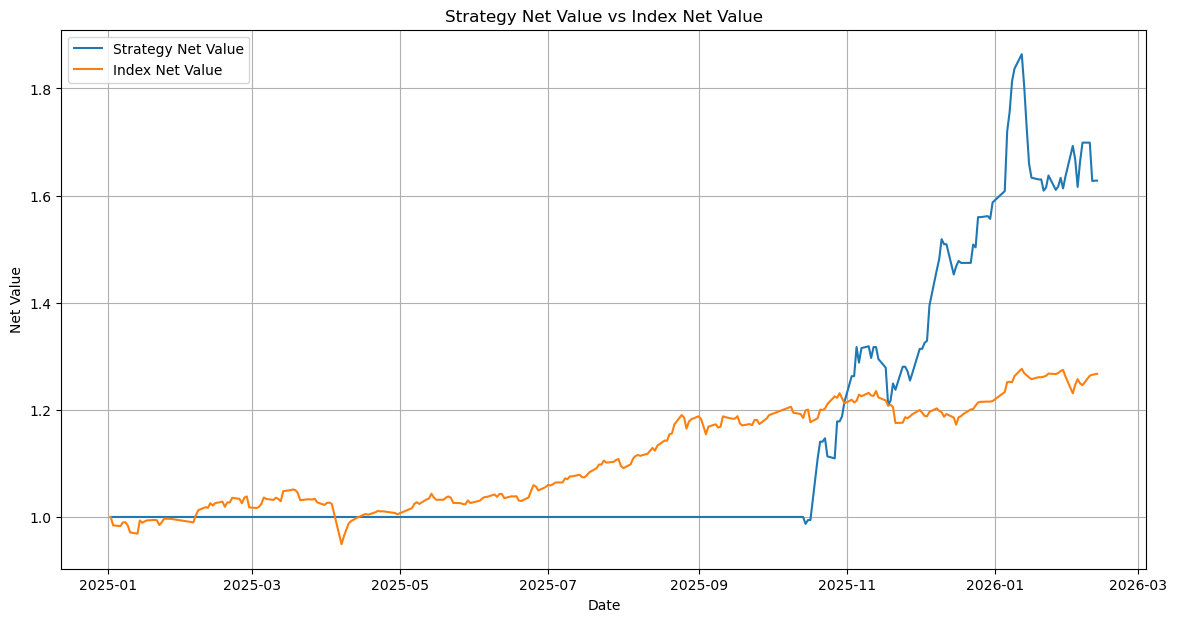

回测结果(触及跌停风控):

回测时间:2025-01-02 - 2026-02-12
策略胜率: 58.59%
策略盈亏比: 1.72
每日平均开仓个数: 3.24
平均持仓天数: 1.66 天
每单位风险期望收益:0.5920
策略总收益率: 75.23%
策略年化收益率: 65.58%
最大回撤: -9.20%
最大回撤阶段: 2025-11-10 至 2025-11-21
夏普比率: 2.35
策略超额年化收益率: 41.86%
最终净值: 1.7523


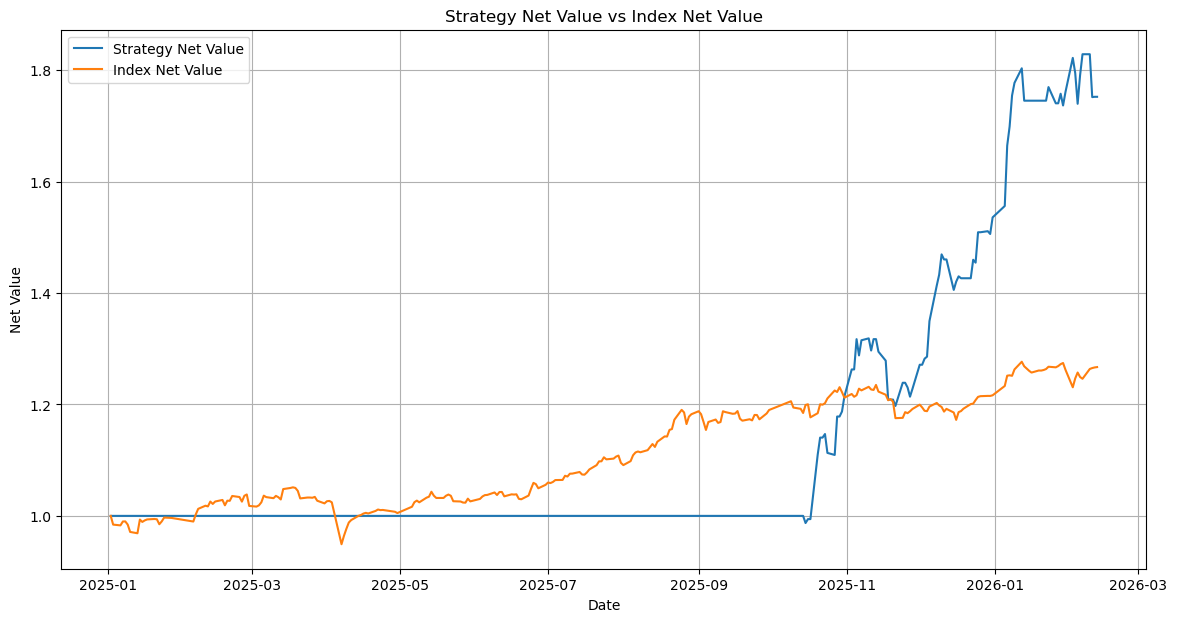

In [5]:
from trade_fun import report_backtest_full
from fun import *
from trade_fun import adjust_weight_by_near_n, adjust_weight_by_consecutive_losses # 触及跌停调仓

# 1.仓位控制风控(merged_df_with_weight)
merged_df_with_weight = adjust_weight_by_near_n(merged_df,return_column='weight_touch_limit_down') 
"""触及跌停风控"""
# 2.连续亏损风控
merged_df_with_weight = adjust_weight_by_consecutive_losses(merged_df_with_weight,return_column='weight_consec_loss')
merged_df_with_weight = merged_df_with_weight.with_columns(
    pl.when(pl.col("weight_touch_limit_down") == pl.col("weight_consec_loss")) # 相等时取任意一列的值（结果一致）
    .then(pl.col("weight_touch_limit_down"))  # 相等时取任意一列的值（结果一致）
    .otherwise(pl.min_horizontal("weight_touch_limit_down", "weight_consec_loss"))  # 不等时取最小值
    .alias("weight")
)
merged_df_with_weight = merged_df_with_weight.with_columns(
    (pl.col("profit") * pl.col("weight")).alias("weight_profit")
)
#merged_df_with_weight.write_csv(filename, include_bom=True)

# 买点下移风控(merged_df_with_weight_adjust)
rate_move = 0.02
# 增加买点下移的逻辑（当weight=0时,如果low<=open*(1-rate_move)时,买点下移rate_move（也就是profit+rate_move*100），否则profit=0）
merged_df_with_weight_adjust = merged_df_with_weight.with_columns(
    pl.when(pl.col("weight") != 0)
    # 条件1：weight≠0 → 保持原profit不变
    .then(pl.col("profit"))
    # 条件2：weight==0 → 进一步判断low是否满足下移条件
    .otherwise(
        pl.when(pl.col("low") <= pl.col("open") * (1 - rate_move))
        # 子条件1：满足下移 → profit+rate_move*100
        .then(pl.col("profit") + rate_move * 100)
        # 子条件2：不满足下移 → profit=0
        .otherwise(0)
    ).alias("profit")  # 覆盖原profit列
) #买点下移回测
"""买点下移风控"""
merged_df_with_weight_adjust = merged_df_with_weight_adjust.with_columns(
    (pl.col("profit") *0.4).alias("weight_profit")
)

merged_df = merged_df.with_columns((pl.col("profit") *0.4).alias("weight_profit"))
result_df['weight_profit'] = result_df['profit'] *0.4


# 回测结果汇报
logging.info("回测结果(不风控):")
back_result =report_backtest_full(merged_df.to_pandas(), start_date = '2025-01-01', end_date=end_date_str,profit_col='weight_profit',)
logging.info("回测结果(触及跌停风控):")
back_result =report_backtest_full(merged_df_with_weight.to_pandas(), start_date = '2025-01-01', end_date=end_date_str,profit_col='weight_profit',)
#logging.info("回测结果(买点下移风控):")
#back_result =report_backtest_full(merged_df_with_weight_adjust.to_pandas(), start_date = '2025-01-01', end_date=end_date_str,profit_col='weight_profit')
# 将回测结果保存到日志中
#logging.info("\n" + back_result.to_string(index=False)) 

In [6]:
# 从merged_df_with_weight筛选今天的交易股票和权重
today_trades = merged_df_with_weight.filter(pl.col("trading_date") == today)
code_list = today_trades['code'].to_list()
name_list = today_trades['name'].to_list()
open_list = today_trades['open'].to_list()
weight_list = today_trades['weight'].to_list()
仓位 = weight_list[0] if weight_list else 0
#weight_list = [weight/len(weight_list) if weight > 0 else 0 for weight in weight_list]  # 将权重小于等于0的调整为0
print('日期：{}'.format(today))
print(f"今天的所有信号的股票:")
for i, (code, name) in enumerate(zip(code_list, name_list)):
    print(f"  {i+1}. {code} - {name} - 仓位: {仓位:.4f}")

日期：2026-02-13
今天的所有信号的股票:
  1. SZSE.000892 - 欢瑞世纪 - 仓位: 0.4000


In [ ]:
# qmt下单
from my_qmt import *
from mapping import convert_code_format
import time 
asset = xt_trader.query_stock_asset(ID)
print('-'*18,'【{0}】'.format(asset.account_id),'-'*18) 
if asset:print(f"资产总额: {asset.total_asset}\n"  
                f"持仓市值：{asset.market_value}\n"
                f"可用资金：{asset.cash}\n")
# 给today_trades增加一列分配资金,分配资金=min(可用资金,总资产*仓位)
available_cash = min(asset.cash, asset.total_asset * 仓位)
available_cash = asset.total_asset * 仓位  # 直接使用可用资金进行分配
allocated_cash = available_cash / len(code_list) if len(code_list) > 0 else 0
print(f"分配资金{available_cash:.2f}, 每单分配资金: {allocated_cash:.2f} ")
# 记录开始时间
start_time = time.time()

# 批量异步下单：5笔订单，瞬间提交
seq_list = []  # 存所有请求序号
for i, (code, open_price) in enumerate(zip(code_list, open_list)):
    # 计算每单股票数量
    if allocated_cash > 0 and open_price > 0:
        order_vol = int(allocated_cash / open_price / 100) * 100  # 按照100股整数倍下单
    else:
        print(f"无法下单 {code}，分配资金: {allocated_cash:.2f}, 开盘价: {open_price:.2f}")
        continue  # 跳过这单
    
    print(f"提交第{i+1}单（异步）")
    # 异步下单：这行代码0.001秒就完成，只返回请求序号，不等待券商处理
    seq = xt_trader.order_stock_async(
        account=ID,
        stock_code=convert_code_format(code,format='suffix'),  # 转换成带后缀的格式
        order_type=xtconstant.STOCK_BUY,
        order_volume=order_vol,
        price_type=xtconstant.LATEST_PRICE,
        price=10.5 + i,
        strategy_name="strategy1",
        order_remark=f"async_order_{i+1}"
    )
    seq_list.append(seq)
    print(f"第{i+1}单提交成功，请求序号：{seq}")

# 计算提交5单的耗时
submit_time = time.time() - start_time
print(f"异步批量提交5单总耗时：{submit_time:.3f}秒")

# 后续：券商后台同时处理这5单，1秒后通过回调返回所有订单号
# 这里模拟等待回调结果（实际是自动触发on_order_stock_async_response）
time.sleep(1)
print("全部处理完成，回调收到所有订单号")

------------------ 【51318497】 ------------------
资产总额: 32390.92
持仓市值：32268.0
可用资金：122.12

分配资金12956.37, 每单分配资金: 12956.37 
提交第1单（异步）
第1单提交成功，请求序号：6
异步批量提交5单总耗时：0.001秒
异步委托回调 async_order_1
委托报错回调 async_order_1 本方最优价格买入 [SZ000892] [COUNTER] [120141][证券交易未初始化]
[init_date=20260213,curr_date=20260223]

全部处理完成，回调收到所有订单号
